**Цель**

Построить агента, который сможет end2end выполнять суммаризацию записей в json файле. Обращу вниманию, что мы не пишем цикл в питоне и просто для каждого файла вызываем ллм-ку с инструкцией суммаризировать статью, а ллм-ка сама должна уметь брать файл, читать его, находить статьи, вызывать суммаризатор и потом сохранять файл с результатами.

**Данные**

[articles.json 15271](attachment:/api/attachments.redirect?id=8edbca54-4944-4217-b55a-655df3643a8a)

**Что сделать**

Эту дз можно делать локально на компьютере, мощностей точно хватит, так как все вычисления облачные. Нужно будет поставить питон, поставить среду выполнения, установить туда все зависимости.

- Взять ллм по апи
  - [инструкция](https://lokismentor.yonote.ru/doc/zadacha-rag-bAH77R5VXr) по получению ллм-ки в groq
- Добавить тулы для агента
  - чтение файла
  - суммаризация
  - сохранение результата
- Использовать mcp, langchain, langgraph
- Описать в ридми решение, максимально подробно, прям вот по каждой функции, что как делали, как запускать агента и тд

**Советы**

Используйте ИИ-ассистентов!

In [1]:
import os, sys
from pathlib import Path

import json

from groq import Groq

__file__ = os.getcwd()

ROOT_DIR = Path(__file__).resolve().parent

In [12]:
from openai import OpenAI

In [2]:
with open(ROOT_DIR/'data/articles.json', encoding='utf-8') as f:
    articles = json.load(f)

In [18]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
with open("../config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [3]:
GROQ_API=os.getenv('GROQ_API')
GROQ_MODEL = config['GROQ_MODEL']
TEMPERATURE = config['TEMPERATURE']
MAX_TOKENS = config['MAX_TOKENS']

In [4]:
client_groq = Groq(
    api_key=GROQ_API,
)

In [14]:
client_lmstudio = OpenAI(
    base_url="http://10.98.65.86:5985/v1",
    api_key="lm-studio",  # LM Studio обычно не проверяет ключ
)

In [90]:
OPENROUTER_API = os.getenv('OPENROUTER_API')
OPENROUTER_MODEL = 'deepseek/deepseek-v4-flash-0731'

In [21]:
client_openrouter = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API,
)

In [22]:
def generate_answer(content='hi', client=client_groq, model=GROQ_MODEL):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": """
                Отвечай только на вопрос.
                Максимум 30 слов.
                Только один короткий абзац.
                Без Markdown, списков и таблиц.
                """
            },
            {
                "role": "user",
                "content": content
            }
        ],
        temperature=TEMPERATURE,
        max_tokens=MAX_TOKENS,
        extra_body={
            "reasoning_effort": "low"
        }
    )
    return completion.choices[0].message.content

In [23]:
generate_answer(client=client_lmstudio, model=GROQ_MODEL, content='ты уверен?')

'\n\nЯ стараюсь быть точным, но не могу гарантировать абсолютную уверенность без полного контекста вопроса.'

# Вариант 1. LangChain (baseline)
```
User
 |
 v
LLM Agent (LangChain)
 |
 +-- Tool: read_file
 |
 +-- Tool: summarize_article
 |
 +-- Tool: save_result
 |
 v
output.json
```

Стек:
* LangChain
* Tool calling
* OpenAI/Groq/local LLM

In [24]:
import json
from pathlib import Path

from langchain_core.tools import tool


@tool
def read_file(path: str):
    """
    Читает json файл со статьями.
    """

    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    # return json.dumps(data, ensure_ascii=False)
    return data
    

In [25]:
data = read_file.invoke(
    {
        "path": "../data/articles.json"
    }
)

In [26]:
import yaml

In [27]:
import ast
from typing import List

In [28]:
"С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на суточные для сотрудников уровня Specialist и Senior составляет 2500 рублей в сутки, для руководителей групп — 3500 рублей. Покупка авиабилетов допускается только в эконом-классе, исключение возможно при перелете длительностью более 8 часов и наличии медицинского заключения. Все закрывающие документы необходимо загрузить в течение 7 календарных дней после возвращения. Если документы не загружены в срок, бухгалтерия переносит расходы в статус личных и удерживает сумму из ближайшей выплаты."

'С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на суточные для сотрудников уровня Specialist и Senior составляет 2500 рублей в сутки, для руководителей групп — 3500 рублей. Покупка авиабилетов допускается только в эконом-классе, исключение возможно при перелете длительностью более 8 часов и наличии медицинского заключения. Все закрывающие документы необходимо загрузить в течение 7 календарных дней после возвращения. Если документы не загружены в срок, бухгалтерия переносит расходы в статус личных и удерживает сумму из ближайшей выплаты.'

In [34]:
import json
from pathlib import Path

from langchain_core.tools import tool


@tool
def read_file(path: str) -> List[dict]:
    """
    Читает json файл со статьями
    
    Примеры:
    [
     {'id': '1', 'title': ..., 'text': ...},
     {'id': '2', ...}
    ]
    """

    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    # return json.dumps(data, ensure_ascii=False)
    return data
    

@tool
def summarize_article(data: List[dict], client=client_openrouter) -> List[dict]:
    """
    Суммаризирует данные 

    input:
    [
     {'id': '1', 'title': ..., 'text': some_text},
     {'id': '2', ...}
    ]

    output:
    [
     {'id': '1', 'title': ..., 'text': summarized_text},
     {'id': '2', ...}
    ]
    """
    res = []
    if isinstance(data, str):
        _data = ast.literal_eval(data)
    else:
        _data = data
    for doc in _data:
        prompt = f"""
        Сделай краткое резюме статьи (суммаризацию):
    
        {doc['text']}
    """
        _ = generate_answer(content=prompt, client=client, model=GROQ_MODEL)
        doc['text'] = clean_text(_)
        res.append(doc)
    return res

@tool
def save_results(results: str):
    """
    Сохраняет результаты суммаризации List[dict] в json файл.
    """

    output_path = Path("../output/summaries.json")

    output_path.parent.mkdir(exist_ok=True)
    _results = ast.literal_eval(results)

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(
            _results,
            f,
            ensure_ascii=False,
            indent=2
        )
    
    return "Файл успешно сохранен"

## test tools

In [30]:
data = read_file.invoke(
    {
        "path": "../data/articles.json"
    }
)

In [41]:
def clean_text(text):
    replacements = {
        "\u202f": " ",  # narrow no-break space
        "\xa0": " ",    # non-breaking space
        "\n": " ",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text.strip()

In [35]:
summ = summarize_article.invoke(
    {
        "data": data
    }
)
print(summ[0])

{'id': '1', 'title': 'Регламент оформления командировок и возмещения расходов', 'text': 'С 1\u202fянв\u202f2026: заявки в TravelHub за\u202f5\u202fраб. дней; проживание – 9\u202f000\u202f₽, 12\u202f000\u202f₽, 160\u202f€; суточные – 2\u202f500\u202f₽, 3\u202f500\u202f₽; билеты только эконом, исключения >8\u202fч с мед. заключением; документы ≤7\u202fдн, иначе расходы личные.'}


In [45]:
save_results.invoke(
    {
        "results": str(summ)
    }
)

'Файл успешно сохранен'

In [105]:
"С 1 января 2026 года действует обновленный регламент командировок. Заявка оформляется в TravelHub не позднее чем за 5 рабочих дней до выезда и согласуется руководителем подразделения и финансовым контролером. Лимиты проживания: 9000 руб./ночь по России, 12000 руб. по СНГ, 160 евро по Европе. Суточные: 2500 руб. для Specialist/Senior, 3500 руб. для руководителей групп. Авиабилеты — только эконом-класс, исключение при перелете более 8 часов и наличии медзаключения. Закрывающие документы загружаются в течение 7 дней после возвращения; при просрочке расходы переводятся в статус личных и удерживаются из ближайшей выплаты."

'С 1 января 2026 года действует обновленный регламент командировок. Заявка оформляется в TravelHub не позднее чем за 5 рабочих дней до выезда и согласуется руководителем подразделения и финансовым контролером. Лимиты проживания: 9000 руб./ночь по России, 12000 руб. по СНГ, 160 евро по Европе. Суточные: 2500 руб. для Specialist/Senior, 3500 руб. для руководителей групп. Авиабилеты — только эконом-класс, исключение при перелете более 8 часов и наличии медзаключения. Закрывающие документы загружаются в течение 7 дней после возвращения; при просрочке расходы переводятся в статус личных и удерживаются из ближайшей выплаты.'

In [46]:
from langchain_groq import ChatGroq

from langchain.agents import create_agent
llm = ChatGroq(
    model=GROQ_MODEL,
    temperature=TEMPERATURE,
    api_key=GROQ_API
)

In [107]:
# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     model="qwen/qwen3.5-9b",
#     temperature=TEMPERATURE,
#     api_key="lm-studio",   # LM Studio принимает любое значение
#     base_url="http://10.98.65.86:5985/v1"
# )

In [47]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=OPENROUTER_MODEL,
    temperature=TEMPERATURE,
    api_key=OPENROUTER_API,
    base_url="https://openrouter.ai/api/v1",
)

In [48]:
from langchain_core.callbacks import BaseCallbackHandler


class ToolLogger(BaseCallbackHandler):

    def on_tool_start(
        self,
        serialized,
        input_str,
        **kwargs
    ):
        print("\n TOOL START:")
        print(serialized["name"])
        print("INPUT:")
        print(input_str)


    def on_tool_end(
        self,
        output,
        **kwargs
    ):
        print("\n TOOL END:")
        print(output)

In [49]:
tools = [
    read_file,
    summarize_article,
    save_results
]

In [50]:
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="""
    Ты агент для суммаризации.

    Нужно:
    1. Прочитать JSON.
    2. Суммаризировать файл.
    3. Сохранить результат суммаризации в виде JSON.
    """
)

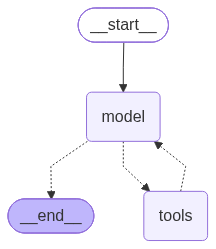

In [139]:
agent

In [ ]:
debug = False

In [54]:
a = {'a':'b'}
a.update({'b':'c'})

In [ ]:
agent_config = {
        "recursion_limit": 20, 
        "debug": True
    }
if debug:
    agent_config.update({
        "callbacks": [
            ToolLogger()
        ]})
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content":
                "Сделай суммаризацию ../data/articles.json"
            }
        ]
    },
    config=agent_config
)

In [78]:
result.keys()

dict_keys(['messages'])

In [60]:
result['messages'][5].dict()

C:\Users\User\AppData\Local\Temp\ipykernel_27124\2325179070.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  result['messages'][5].dict()


{'content': '',
 'additional_kwargs': {'refusal': None},
 'response_metadata': {'token_usage': {'completion_tokens': 1286,
   'prompt_tokens': 7287,
   'total_tokens': 8573,
   'completion_tokens_details': {'accepted_prediction_tokens': None,
    'audio_tokens': 0,
    'reasoning_tokens': 0,
    'rejected_prediction_tokens': None,
    'image_tokens': 0},
   'prompt_tokens_details': {'audio_tokens': 0,
    'cache_write_tokens': 0,
    'cached_tokens': 3072,
    'video_tokens': 0},
   'cost': 0.000518098,
   'is_byok': False,
   'cost_details': {'upstream_inference_cost': 0.000518098,
    'upstream_inference_prompt_cost': 0.000338058,
    'upstream_inference_completions_cost': 0.00018004}},
  'model_provider': 'openai',
  'model_name': 'deepseek/deepseek-v4-flash-0731',
  'system_fingerprint': None,
  'id': 'gen-1787344157-nta3w3zIQ35Q8RthPCZf',
  'finish_reason': 'tool_calls',
  'logprobs': None},
 'type': 'ai',
 'name': None,
 'id': 'lc_run--01a02603-7634-7ac0-a522-bf6a845eace2-0',
 't

# Вариант 2. LangGraph (более правильная архитектура)
```
             START
               |
               v
        Read JSON Node
               |
               v
       Summarization Node
               |
               v
        Validation Node
               |
               v
        Save JSON Node
               |
               v
              END```

In [61]:
from typing import TypedDict, List

## Создаю объект, который будет путешествовать между узлами.

In [62]:
class SummaryState(TypedDict):
    path: str
    articles: List[dict]
    summaries: List[dict]

В LangGraph node — это обычная функция.

In [63]:
import json

def read_file_node(state: SummaryState):

    with open(
        state["path"],
        encoding="utf-8"
    ) as f:
        articles = json.load(f)


    return {
        "articles": articles
    }

## Переношу логику

In [89]:
def summarize_node(state: SummaryState, client=client_openrouter, model_name='modelname'):

    summaries = []

    for article in state["articles"]:

        prompt = f"""
        Сделай краткое резюме статьи.

        Максимум 30 слов.

        Текст:

        {article['text']}
        """


        summary = generate_answer(
            content=prompt,
            client=client,
            model=model_name
        )


        article_copy = article.copy()

        article_copy["text"] = summary

        summaries.append(article_copy)


    return {
        "summaries": summaries
    }

In [91]:
def summarize_node_openrouter(state: SummaryState):
    return summarize_node(state=state, client=client_openrouter, model_name=OPENROUTER_MODEL)

In [65]:
def save_node(state: SummaryState):

    output_path = Path(
        "../output/summaries.json"
    )

    output_path.parent.mkdir(
        exist_ok=True
    )


    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            state["summaries"],
            f,
            ensure_ascii=False,
            indent=2
        )

    return {}

In [66]:
from langgraph.graph import StateGraph, START, END

## Собираю граф

In [92]:
graph = StateGraph(
    SummaryState
)


graph.add_node(
    "read_file",
    read_file_node
)


graph.add_node(
    "summarize",
    summarize_node_openrouter
)


graph.add_node(
    "save",
    save_node
);

## Соединяю

In [93]:
graph.add_edge(
    START,
    "read_file"
)


graph.add_edge(
    "read_file",
    "summarize"
)


graph.add_edge(
    "summarize",
    "save"
)


graph.add_edge(
    "save",
    END
)

## Тещу ноды

In [77]:
def test_read_file_node():

    state = {
        "path": "../data/articles.json"
    }

    result = read_file_node(state)

    assert "articles" in result
    assert isinstance(result["articles"], list)

    assert len(result["articles"]) > 0

    article = result["articles"][0]

    assert "id" in article
    assert "title" in article
    assert "text" in article

    print("✅ read_file_node OK")

In [78]:
test_read_file_node()

✅ read_file_node OK


In [76]:
def fake_generate_answer(content, client, model):
    return "Краткое тестовое резюме статьи."

In [81]:
generate_answer_backup = generate_answer
generate_answer = fake_generate_answer

In [82]:
def test_summarize_node():

    state = {
        "articles": [
            {
                "id": "1",
                "title": "Тестовая статья",
                "text": "Очень длинный текст статьи."
            }
        ]
    }


    result = summarize_node(state)


    assert "summaries" in result

    assert len(result["summaries"]) == 1


    summary = result["summaries"][0]


    assert summary["id"] == "1"

    assert summary["text"] == (
        "Краткое тестовое резюме статьи."
    )


    print("✅ summarize_node OK")

In [83]:
test_summarize_node()

✅ summarize_node OK


In [84]:
generate_answer = generate_answer_backup

In [85]:
def test_save_node():

    state = {
        "summaries": [
            {
                "id": "1",
                "title": "Тест",
                "text": "Summary"
            }
        ]
    }


    result = save_node(state)


    output = Path(
        "../output/summaries.json"
    )


    assert output.exists()


    with open(
        output,
        encoding="utf-8"
    ) as f:

        data = json.load(f)


    assert len(data) == 1

    assert data[0]["text"] == "Summary"


    print("✅ save_node OK")

In [102]:
test_save_node()

✅ save_node OK


## Выполняю graph

In [94]:
app = graph.compile()

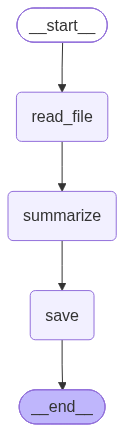

In [87]:
app

In [88]:
result = app.invoke(
    {
        "path": "../data/articles.json"
    }
)

# Вариант 3. MCP + LangChain
```
              LLM
               |
          MCP Client
               |
        MCP Server
          /   |   \
 read_file summarize save

 MCP server tools/
 ├── read_json()
 ├── summarize()
 └── save_json()

 LLM
 |
MCP tools
```


Структура MCP:
```
mcp_project/

├── mcp/
│   └─ server/
│   │   └── server.py
│   └─ client/
│       └── agent.py
│
└── data/
    └── articles.json
```

Реализовано в соответсвующих файлах agent.py, server.py и вызывается как python mcp/client/agent.py